# Project: Visualizing The Stock Market: Decoding the S&P 500

> *"We search through historical data to find anomalies... We don't start with models. We start with data."* — **Jim Simons**, Mathematician, Philantrophist & Founder of Renaissance Technologies.

---

### The Mission
Welcome, Analyst. You are no longer just a student; today, you are a quantitative researcher entering the high-dimensional arena of the S&P 500. 

In the world of elite hedge funds, the market is not viewed as a simple list of stock prices. It is seen as a chaotic, breathing ecosystem of **signals buried in mountains of noise.** The legends of the field (Jim Simons, Ken Griffin, Ray Dalio) didn't build their empires by following the news. They built them by developing a "visual intuition" for the invisible structures that govern the global economy.

### The Challenge
How do you visualize 500 companies moving simultaneously across thousands of days? How do you see the "DNA" of a sector or the hidden gravitational pull that one stock exerts on another? 

This project is designed to take you from raw data ingestion to the **Frontier of Alpha**. Over the course of this notebook, you will:

1.  **Ingest the Pulse:** Stream 5 years of market-wide data, learning to spot the "gaps" where information is lost.
2.  **Expose the Skeleton:** Use hierarchical clustering to reveal the "tribes" of the market—seeing how stocks group together regardless of their official sector labels.
3.  **Warp Dimensions:** Apply advanced dimensionality reduction techniques: **PCA (Principal Component Analysis)** and **t-SNE**, to compress a 500-dimensional market into a 2D "map" you can actually navigate.

### The Goal
By the end of this investigation, you won't just see a line chart. You will see the **latent clusters** and **anomalous outliers** that the rest of the market is blind to. You are about to build a "GPS" for the financial markets.

---

## 🔧 Step 0: Install Required Packages

**IMPORTANT: Run this cell first!** This will install all the necessary Python packages.

In [1]:
# Install required packages
import sys
import subprocess

packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'plotly',
    'yfinance',
    'scikit-learn',
    'scipy',
    'requests',
    'lxml',
    'html5lib'
]

print("Installing required packages...\n")
for package in packages:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f"✓ {package}")
    except Exception as e:
        print(f"✗ {package}: {e}")

print("\nInstallation complete! You can now run the rest of the notebook.")

Installing required packages...

✓ pandas
✓ numpy
✓ matplotlib
✓ seaborn
✓ plotly
✓ yfinance
✓ scikit-learn
✓ scipy
✓ requests
✓ lxml
✓ html5lib

Installation complete! You can now run the rest of the notebook.


## Plot Style Setup

**Set up the visual style for financial market analysis.**

In [2]:
# Apply a visual "Quant" style
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio

# Setting a dark, high-contrast theme for that "Trading Floor" feel
plt.style.use('dark_background')
sns.set_context("talk")
custom_params = {"axes.spines.right": False, "axes.spines.top": False, "grid.alpha": 0.1}
sns.set_theme(style="darkgrid", rc=custom_params)

# For interactive Plotly charts, we use a dark template
pio.templates.default = "plotly_dark"

print("✓ Visual style configured")

✓ Visual style configured


## Part 1: Getting and cleaning the data

**The Objective:** 
In quantitative finance, your model is only as good as your data—a concept known as *Garbage In, Garbage Out*. A true Quant doesn't just download a CSV; they investigate the "health" of their data before a single trade is placed. 

In this part, you will fetch the daily historical data for the current S&P 500 constituents. While it is tempting to use a small subset, we want to see the *entire* universe to understand systemic risk. We will use the `yfinance` library to scrape this data from the web.

### Your Tasks:
1.  **Retrieve Tickers:** Programmatically retrieve the list of current S&P 500 tickers (Hint: Wikipedia's "List of S&P 500 companies" table is the industry-standard source for this).
2.  **Download Historical Data:** Download the last **5 years** of daily data for these tickers. Focus specifically on the **Adjusted Close** price. 
    *   *Note: Downloading 500+ tickers may take a few minutes. If your hardware is struggling, you may choose to proceed with a subset (e.g., the first 100 tickers), but try for the full set first!*
3.  **Visualize Data Completeness:** Create a "Missingness Map" or a "Data Integrity Heatmap." In finance, missing data is often a "trap" (e.g., a company was delisted, merged, or newly added). You need to visualize which stocks have gaps or incomplete histories.

### Critical Thinking Questions:
*   **Price vs. Adjusted Price:** Why do quantitative analysts almost exclusively use "Adjusted Close" instead of "Close" when calculating historical returns? (Hint: Think about dividends and stock splits).
*   **The Survival Bias:** By downloading data for the *current* S&P 500 companies, are we ignoring companies that were in the index 5 years ago but went bankrupt or were removed? How might this "Survivorship Bias" skew your final visualizations?
*   **The Imputation Dilemma:** If a stock is missing 5% of its data in the middle of a time series, should you "fill" it using the previous day's price (Forward Fill) or delete the stock from your study entirely? What are the risks of both?

---

📊 PART 1 — DATA ACQUISITION AND CLEANING

Step 1: Retrieving S&P 500 constituents...
✓ Successfully retrieved ticker list (fallback method).
✓ Total tickers retrieved: 503
✓ Sample tickers: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES']

Step 2: Downloading historical price data...
✓ Time range: 2021-02-09 → 2026-02-08
⏳ Downloading adjusted close prices...



[*********************100%***********************]  503 of 503 completed

1 Failed download:
['DOV']: TypeError("'NoneType' object is not subscriptable")


✓ Download completed.
✓ Dataset shape: (1254, 503)
✓ Trading days: 1254
✓ Stocks: 503

Step 3: Analyzing data completeness...
✓ Stocks with >50% missing data: 6
✓ Stocks with >20% missing data: 8
✓ Stocks with >10% missing data: 9

✓ Visualizing missing-data structure...


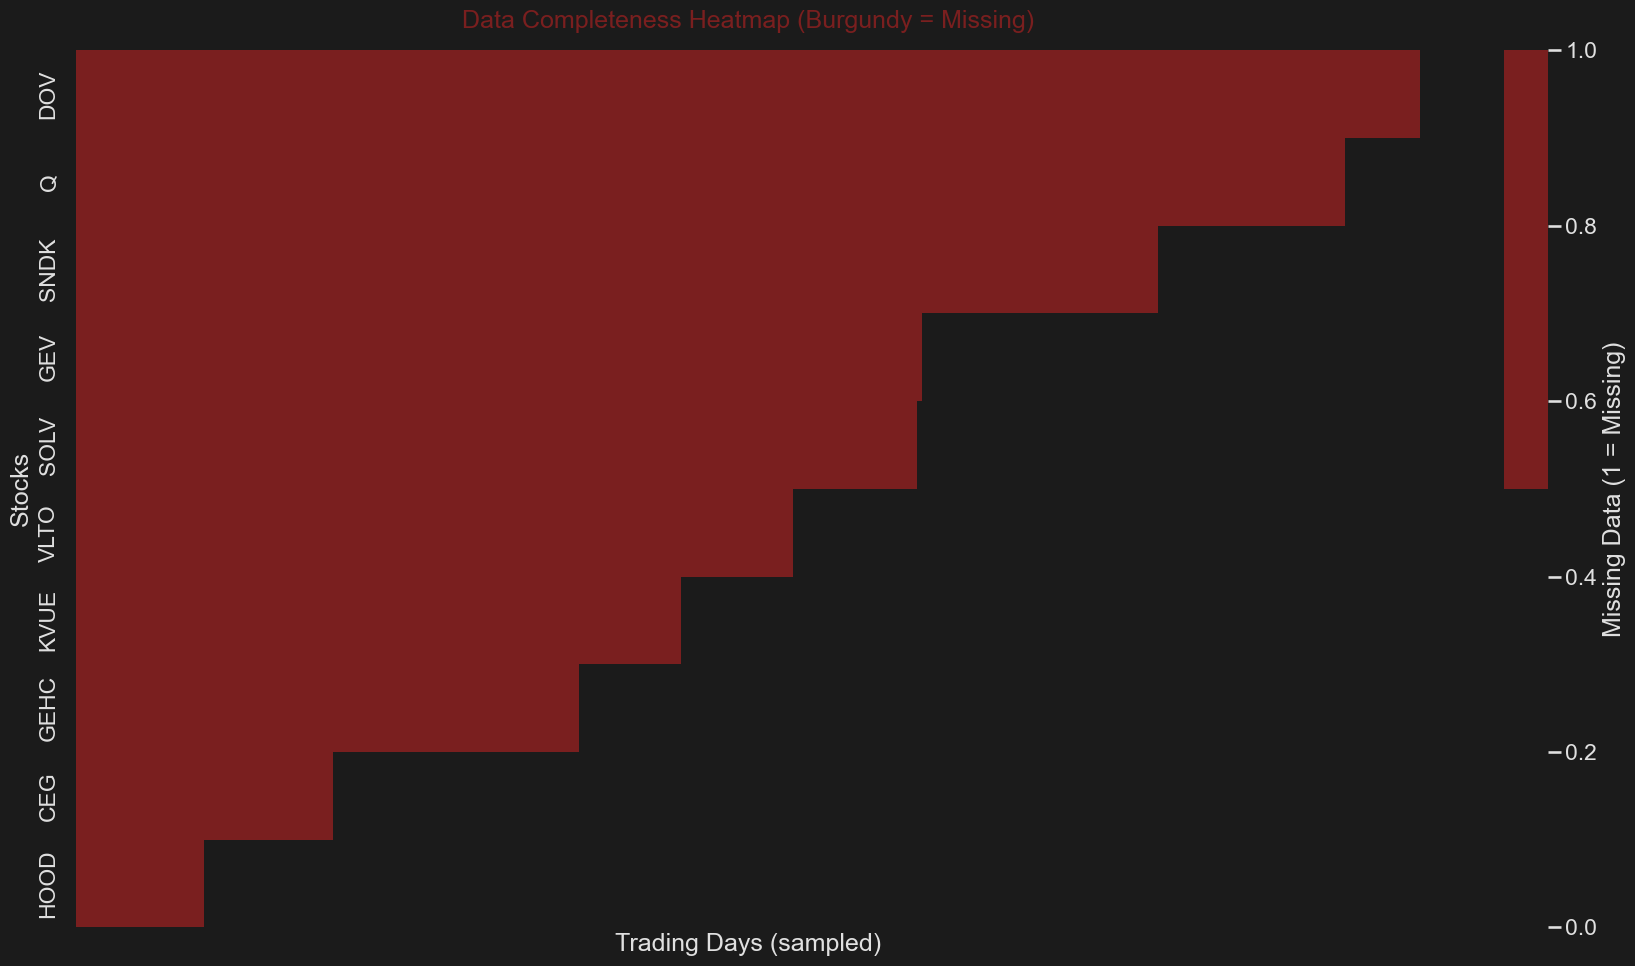

Step 4: Cleaning the dataset...
✓ Cleaning summary:
  • Removed stocks: 8
  • Final shape: (1254, 495)
  • Remaining NaN values: 0

✓ Preview of cleaned closing prices:


Ticker,CEG,HOOD,APP,COIN,FISV,NOW,NVR,NVDA,MSI,NUE,...,ES,ERIE,EQT,EQR,EQIX,EPAM,EOG,EMR,EME,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2021-02-10,40.60939,34.82,65.199997,328.279999,109.419998,117.872002,4701.830078,14.722848,172.502228,50.841496,...,72.064842,235.122543,15.752624,55.252186,682.067139,387.329987,47.151180,76.666389,93.887665,153.145187
2021-02-11,40.60939,34.82,65.199997,328.279999,108.480003,118.893997,4708.330078,15.207982,171.062500,50.739735,...,71.206024,237.368469,15.808986,56.037849,651.823486,392.890015,46.704811,77.214951,92.973564,156.787430
2021-02-12,40.60939,34.82,65.199997,328.279999,109.989998,118.258003,4700.020020,14.919296,170.384995,52.118088,...,70.330711,237.614960,16.588631,55.806286,644.657898,400.269989,47.785496,77.369095,91.853027,158.951782
2021-02-16,40.60939,34.82,65.199997,328.279999,110.199997,117.148003,4650.000000,15.287260,172.530441,53.043144,...,69.273735,233.926605,16.776497,55.558178,624.931396,394.480011,49.414360,77.133362,92.059448,158.579941
2021-02-17,40.60939,34.82,65.199997,328.279999,111.070000,116.188004,4704.399902,14.864202,171.062500,52.728615,...,67.993790,234.300949,18.007019,55.293537,630.689575,391.700012,49.758945,76.952019,90.506454,161.039841


In [3]:
########## Part 1: Data Acquisition and Cleaning ##########

# =========================
# Libraries
# =========================
import pandas as pd
import numpy as np
import requests
import yfinance as yf
from datetime import datetime, timedelta
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

warnings.filterwarnings("ignore")


# =========================
# Visual Theme (Academic: Navy + Burgundy)
# =========================
NAVY = "#2C3E50"        # deep navy (structure, grid)
BURGUNDY = "#7A1F1F"    # accent (missing data, titles)
LIGHT_GRAY = "#E0E0E0"  # labels/ticks
DARK_BG = "#1B1B1B"     # charcoal background

plt.style.use("dark_background")
sns.set_context("talk")

plt.rcParams.update({
    "figure.facecolor": DARK_BG,
    "axes.facecolor": DARK_BG,
    "axes.edgecolor": LIGHT_GRAY,
    "axes.labelcolor": LIGHT_GRAY,
    "axes.titlecolor": BURGUNDY,
    "xtick.color": LIGHT_GRAY,
    "ytick.color": LIGHT_GRAY,
    "grid.color": NAVY,
    "grid.alpha": 0.35,
    "text.color": LIGHT_GRAY
})


print("📊 PART 1 — DATA ACQUISITION AND CLEANING\n")


# =========================
# Step 1: Retrieve S&P 500 Tickers
# =========================
print("Step 1: Retrieving S&P 500 constituents...")

WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

try:
    tables = pd.read_html(WIKI_URL)
    sp500_df = tables[0]
    print("✓ Successfully retrieved ticker list (Wikipedia).")
except Exception:
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(WIKI_URL, headers=headers, timeout=30)
    sp500_df = pd.read_html(response.text)[0]
    print("✓ Successfully retrieved ticker list (fallback method).")

# Yahoo Finance compatibility (e.g., BRK.B -> BRK-B)
tickers = sp500_df["Symbol"].astype(str).str.replace(".", "-", regex=False).tolist()

# Store sector information for later use (e.g., coloring clusters by sector)
sector_map = dict(zip(
    sp500_df["Symbol"].astype(str).str.replace(".", "-", regex=False),
    sp500_df["GICS Sector"]
))

print(f"✓ Total tickers retrieved: {len(tickers)}")
print(f"✓ Sample tickers: {tickers[:8]}\n")


# =========================
# Step 2: Download Historical Prices
# =========================
print("Step 2: Downloading historical price data...")

end_date = datetime.now()
start_date = end_date - timedelta(days=5 * 365)

print(f"✓ Time range: {start_date.date()} → {end_date.date()}")
print("⏳ Downloading adjusted close prices...\n")

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,     # adjusted prices (splits/dividends)
    progress=True,
    threads=True
)

# Extract adjusted close prices
close = data["Close"]

print("✓ Download completed.")
print(f"✓ Dataset shape: {close.shape}")
print(f"✓ Trading days: {close.shape[0]}")
print(f"✓ Stocks: {close.shape[1]}\n")


# =========================
# Step 3: Data Completeness Analysis
# =========================
print("Step 3: Analyzing data completeness...")

missing_pct = (close.isnull().sum() / len(close) * 100).sort_values(ascending=False)

print(f"✓ Stocks with >50% missing data: {(missing_pct > 50).sum()}")
print(f"✓ Stocks with >20% missing data: {(missing_pct > 20).sum()}")
print(f"✓ Stocks with >10% missing data: {(missing_pct > 10).sum()}\n")

stocks_with_missing = missing_pct[missing_pct > 5].index[:30]

if len(stocks_with_missing) > 0:
    print("✓ Visualizing missing-data structure...")

    # 1 = missing, 0 = present
    missing_matrix = close[stocks_with_missing].isnull().astype(int)

    # sample every 5th day for readability/performance
    missing_matrix_sampled = missing_matrix.iloc[::5]

    # Present = background, Missing = burgundy
    cmap = ListedColormap([DARK_BG, BURGUNDY])

    plt.figure(figsize=(18, 10))
    sns.heatmap(
        missing_matrix_sampled.T,
        cmap=cmap,
        cbar_kws={"label": "Missing Data (1 = Missing)"},
        xticklabels=False,
        yticklabels=True
    )
    plt.title("Data Completeness Heatmap (Burgundy = Missing)", pad=16)
    plt.xlabel("Trading Days (sampled)")
    plt.ylabel("Stocks")
    plt.tight_layout()
    plt.show()
else:
    print("✓ No significant missing data detected.\n")


# =========================
# Step 4: Cleaning the Dataset
# =========================
print("Step 4: Cleaning the dataset...")

THRESHOLD = 30  # percent missing allowed
stocks_to_keep = missing_pct[missing_pct < THRESHOLD].index

close_clean = close[stocks_to_keep].copy()

# Fill remaining gaps to ensure a complete matrix for later steps (correlations/clustering/PCA)
close_clean = close_clean.ffill().bfill()

print("✓ Cleaning summary:")
print(f"  • Removed stocks: {close.shape[1] - close_clean.shape[1]}")
print(f"  • Final shape: {close_clean.shape}")
print(f"  • Remaining NaN values: {int(close_clean.isnull().sum().sum())}\n")

print("✓ Preview of cleaned closing prices:")
display(close_clean.head())


## Part 2: Computing Percentage Returns

**The Objective:**  
Price levels themselves are often meaningless when comparing different stocks (e.g., a \$10 stock vs. a \$1000 stock). Quantitative researchers normalize everything into **percentage returns** to ensure comparability. A 2% gain on a \$10 stock and a \$1000 stock is economically identical from a portfolio perspective.

However, you must also be aware of the **compounding effect**. Daily simple returns (percent change from day to day) are the standard for short-term analysis, but over long periods, we use **log returns** to account for compounding.

### Your Tasks:
1.  **Compute Daily Simple Returns:** Calculate the simple percentage change in Adjusted Close for each stock from one day to the next.
2.  **Handle NaNs:** The first row of returns will be `NaN` because there is no prior day to compare it to. Drop or fill these as appropriate.
3.  **Check for Outliers:** Identify days where *individual stocks* had extreme returns (e.g., > 20% in a single day). These could be errors, stock splits that weren't properly adjusted, or major news events.

### Critical Thinking Questions:
*   **Simple vs. Log Returns:** When should you use `log(price_today / price_yesterday)` instead of `(price_today - price_yesterday) / price_yesterday`? (Hint: Think about compounding over multiple periods).
*   **Correlation Stationarity:** Does the correlation between two stocks remain constant over time, or does it evolve? How might you test for "regime changes" in correlation?
*   **Intraday vs. Daily Returns:** This project uses daily closing prices. How might your results change if you used intraday (minute-by-minute) data instead?

---

📈 Computing daily returns...

Returns DataFrame:
Shape: (1253, 495)
Date range: 2021-02-11 to 2026-02-06

First few rows:
Ticker      CEG  HOOD  APP  COIN      FISV       NOW       NVR      NVDA  \
Date                                                                       
2021-02-11  0.0   0.0  0.0   0.0 -0.008591  0.008670  0.001382  0.032951   
2021-02-12  0.0   0.0  0.0   0.0  0.013920 -0.005349 -0.001765 -0.018983   
2021-02-16  0.0   0.0  0.0   0.0  0.001909 -0.009386 -0.010643  0.024664   
2021-02-17  0.0   0.0  0.0   0.0  0.007895 -0.008195  0.011699 -0.027674   
2021-02-18  0.0   0.0  0.0   0.0  0.017827 -0.008848  0.000336 -0.005166   

Ticker           MSI       NUE  ...        ES      ERIE       EQT       EQR  \
Date                            ...                                           
2021-02-11 -0.008346 -0.002002  ... -0.011917  0.009552  0.003578  0.014220   
2021-02-12 -0.003961  0.027165  ... -0.012293  0.001038  0.049317 -0.004132   
2021-02-16  0.012592  0.01774

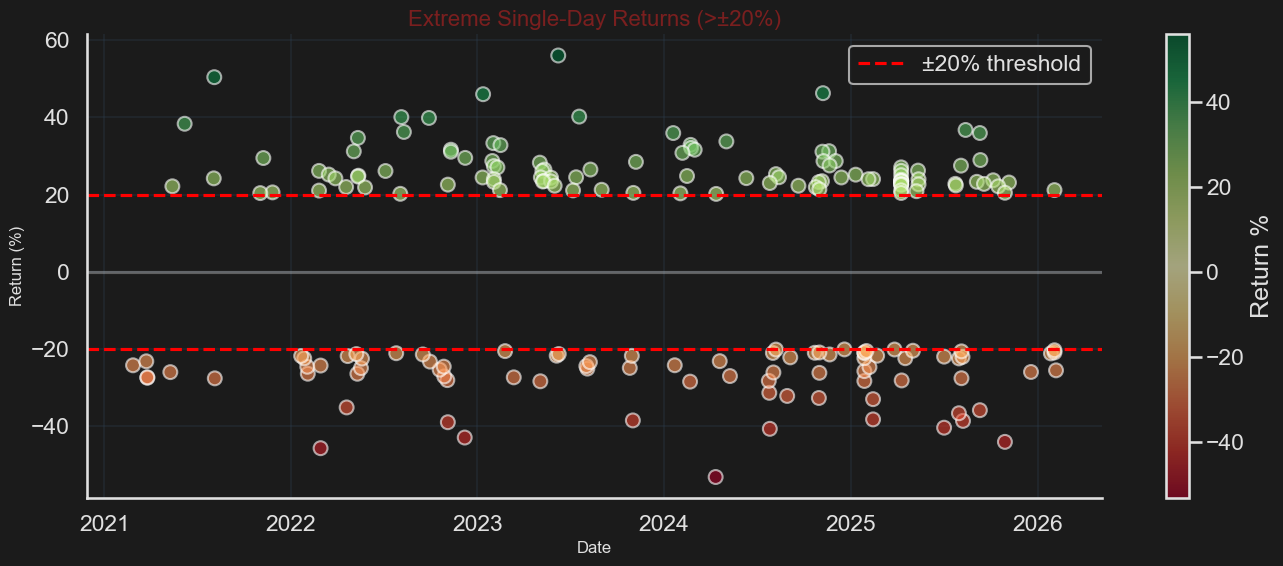

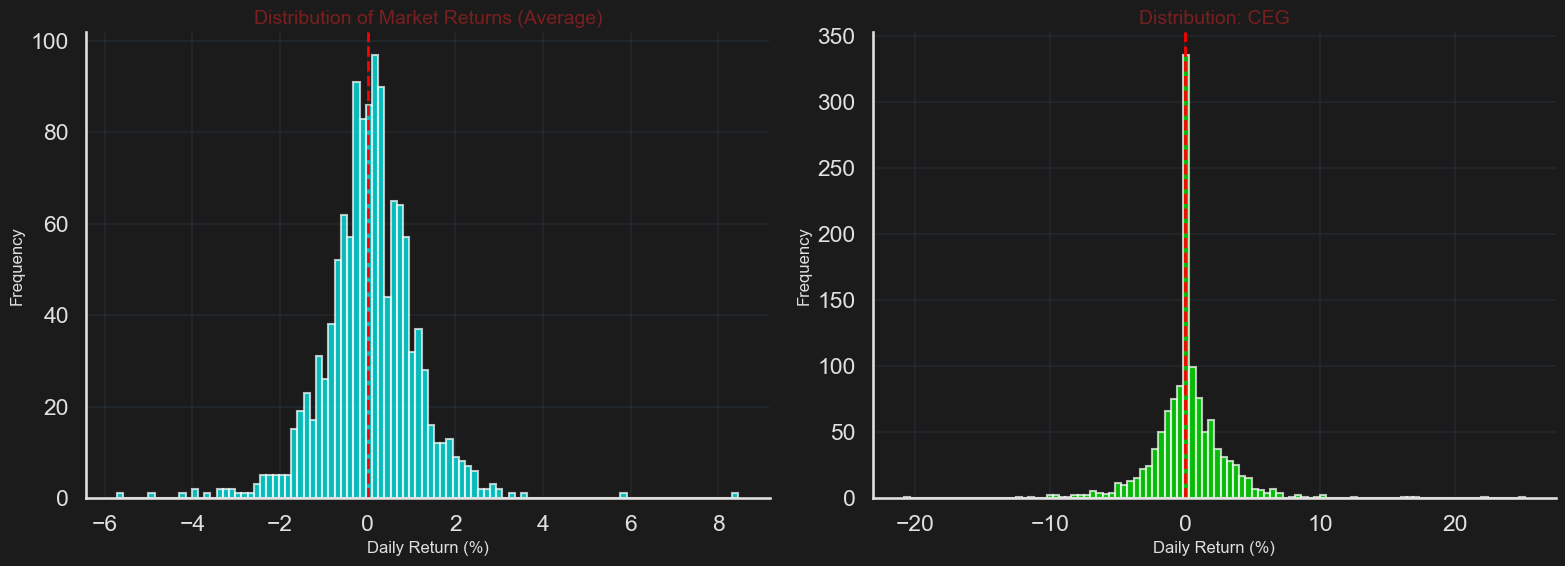


📊 Market Statistics:
Mean daily return: 0.0596%
Std daily return: 1.0494%
Annualized return: 15.03%
Annualized volatility: 16.66%

✅ Part 2 Complete!


In [4]:
########## Write your code in this cell ############
########## Part 2: Computing Percentage Returns ############

print("📈 Computing daily returns...\n")

# 1. Compute daily simple returns
returns = close_clean.pct_change()

# 2. Drop the first row (NaN values)
returns = returns.dropna(how='all')

print("Returns DataFrame:")
print(f"Shape: {returns.shape}")
print(f"Date range: {returns.index[0].date()} to {returns.index[-1].date()}")
print("\nFirst few rows:")
print(returns.head())

print("\nBasic statistics:")
print(returns.describe())

# 3. Check for extreme returns
threshold = 0.20  # 20%

extreme_returns = []
for col in returns.columns:
    extreme = returns[col][abs(returns[col]) > threshold]
    if len(extreme) > 0:
        for date, value in extreme.items():
            extreme_returns.append({
                'Ticker': col,
                'Date': date,
                'Return': value,
                'Return_pct': value * 100
            })

if len(extreme_returns) > 0:
    extreme_df = pd.DataFrame(extreme_returns).sort_values('Return_pct', key=abs, ascending=False)
    print(f"\n⚠️ Found {len(extreme_df)} instances of extreme returns (>±20%):")
    print(extreme_df.head(20))
    
    plt.figure(figsize=(14, 6))
    plt.scatter(
        extreme_df['Date'],
        extreme_df['Return_pct'],
        c=extreme_df['Return_pct'],
        cmap='RdYlGn',
        s=100,
        alpha=0.6,
        edgecolors='white'
    )
    plt.axhline(y=20, color='red', linestyle='--', label='±20% threshold')
    plt.axhline(y=-20, color='red', linestyle='--')
    plt.axhline(y=0, color='white', linestyle='-', alpha=0.3)
    plt.colorbar(label='Return %')
    plt.title('Extreme Single-Day Returns (>±20%)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Return (%)', fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No extreme returns (>±20%) found")

# Distribution of returns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

market_returns = returns.mean(axis=1)
axes[0].hist(market_returns * 100, bins=100, alpha=0.7, color='cyan', edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Daily Return (%)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Market Returns (Average)', fontsize=14)
axes[0].grid(alpha=0.3)

sample_stock = returns.columns[0]
axes[1].hist(returns[sample_stock].dropna() * 100, bins=100, alpha=0.7, color='lime', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Daily Return (%)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Distribution: {sample_stock}', fontsize=14)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Market Statistics:")
print(f"Mean daily return: {market_returns.mean()*100:.4f}%")
print(f"Std daily return: {market_returns.std()*100:.4f}%")
print(f"Annualized return: {market_returns.mean()*252*100:.2f}%")
print(f"Annualized volatility: {market_returns.std()*np.sqrt(252)*100:.2f}%")

# Clean remaining NaN
returns = returns.fillna(0)



## Part 3: Hierarchical Clustering of Stocks

**The Objective:**  
In the hedge fund world, portfolio managers don't group stocks by official "sectors" (Technology, Healthcare, etc.). They group stocks by **behavioral similarity** — how their prices move together. Two stocks might belong to completely different industries but be influenced by the same underlying factors (interest rates, oil prices, consumer sentiment), causing them to cluster behaviorally.

Hierarchical clustering builds a "dendrogram" (tree diagram) that reveals these hidden "tribes" of the market. Stocks that cluster tightly together move in lockstep; stocks in different branches are driven by independent forces.

### Your Tasks:
1.  **Compute Correlation Matrix:** Calculate the pairwise correlation matrix between all stocks based on their daily returns.
2.  **Distance Metric:** Convert correlation into a "distance" metric. Remember: A correlation of +1 means "perfect alignment" (distance = 0), while a correlation of -1 means "perfect opposition" (distance = 2). Use the formula: `distance = 1 - correlation`.
3.  **Perform Hierarchical Clustering:** Use `scipy.cluster.hierarchy.linkage` with the **Ward** method.
4.  **Plot the Dendrogram:** Visualize the hierarchical clustering tree. Color branches to identify distinct clusters.
5.  **Cut the Tree:** Choose a threshold height to "cut" the dendrogram and assign each stock to a cluster ID.

### Critical Thinking Questions:
*   **Linkage Methods:** Why use the "Ward" linkage method instead of "Single" or "Complete"? What does Ward minimize?
*   **Cluster Stability:** If you re-run this analysis on a different 5-year window (e.g., 2015-2020 vs. 2018-2023), would the clusters stay the same? What does this imply about market regimes?
*   **Distance Metric Choice:** We used `distance = 1 - correlation`. What happens if two stocks have a correlation of -0.5? Are they "far apart" or "close together" in behavioral space?

---

🌳 Performing hierarchical clustering...

Correlation Matrix:
Shape: (495, 495)


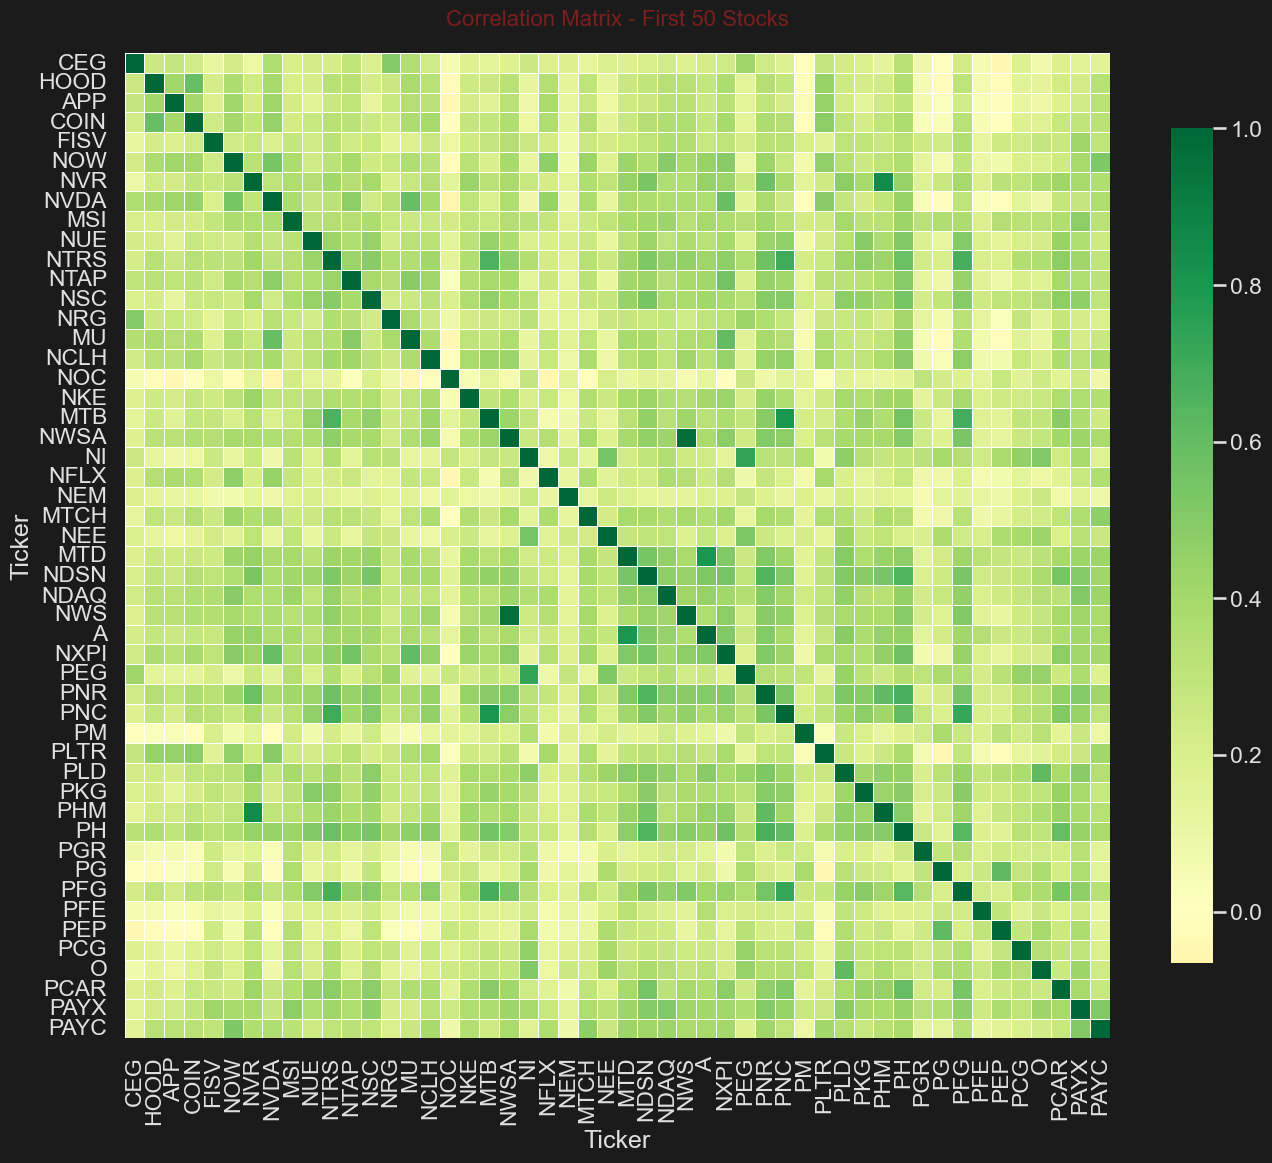


✓ Distance matrix computed
Min distance: 0.0000
Max distance: 1.1671

✓ Hierarchical clustering complete


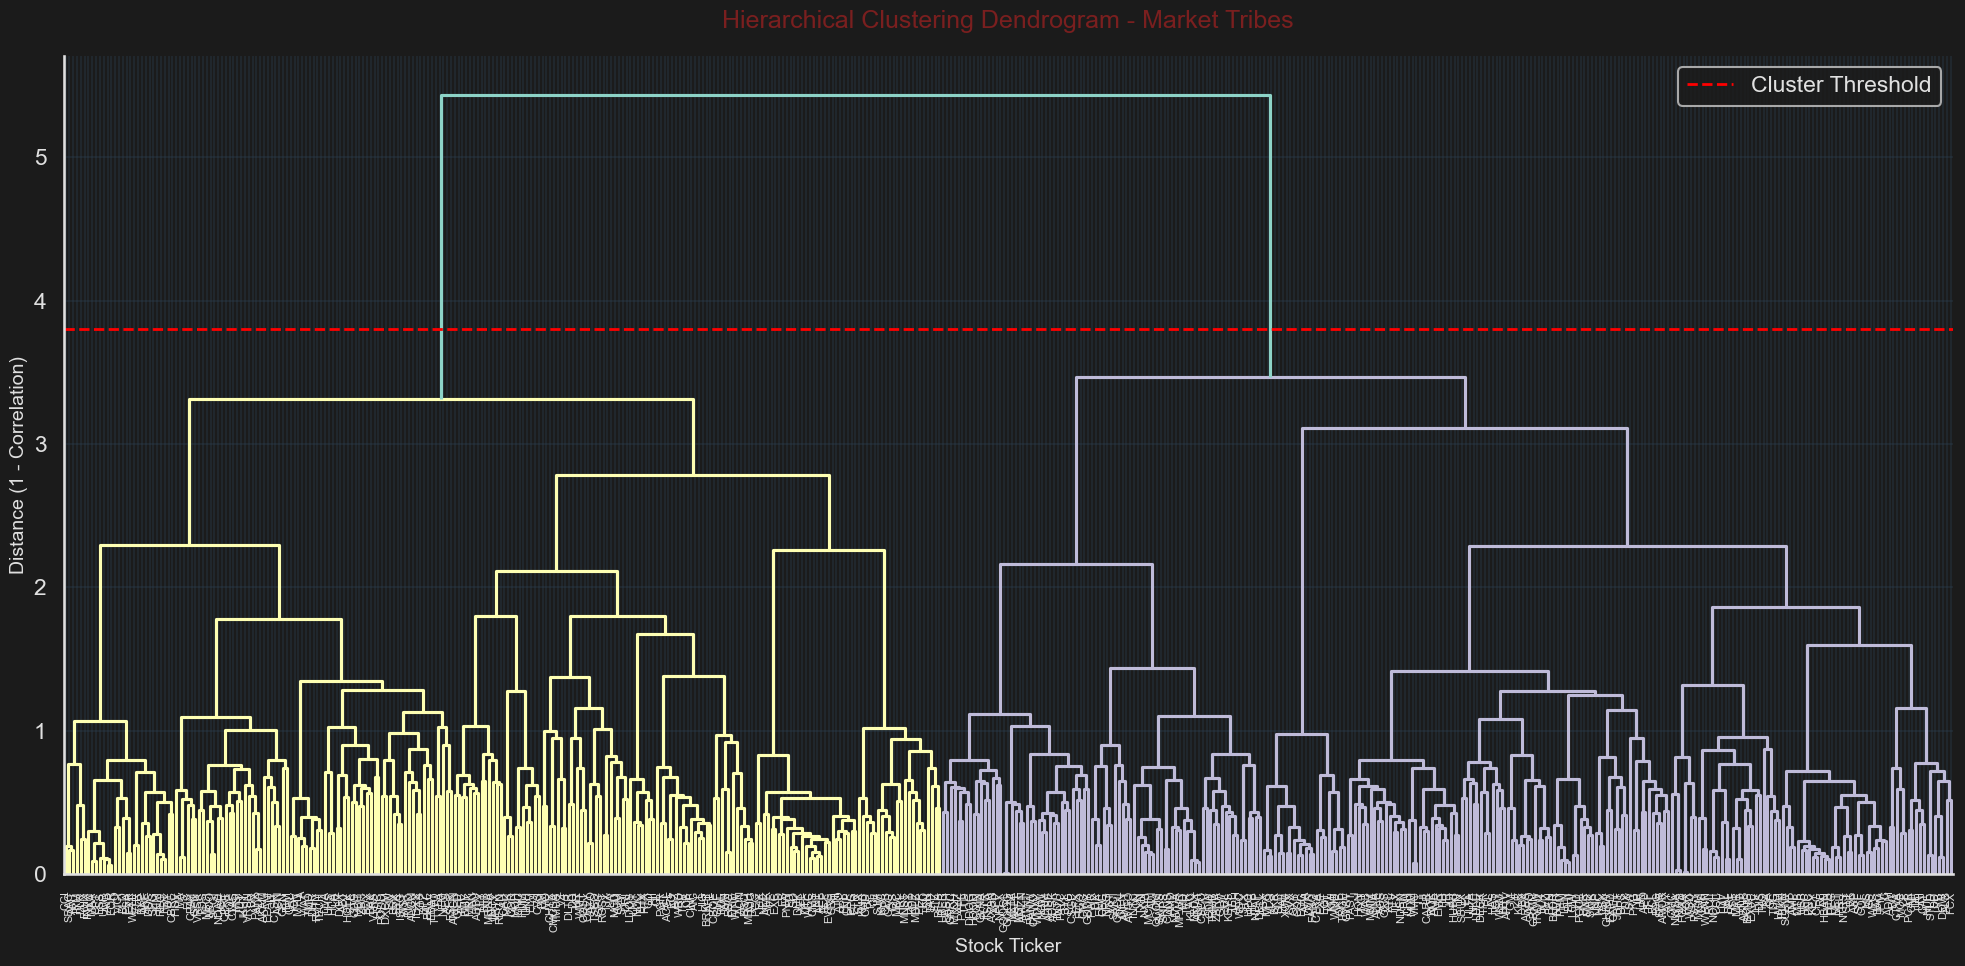


✓ Stocks assigned to 10 clusters

Cluster distribution:
Cluster
1     29
2     73
3     79
4     27
5     22
6     39
7     45
8     22
9     85
10    74
Name: count, dtype: int64

📊 Cluster Analysis:

Cluster 1 (29 stocks):
  Top sectors: {'Real Estate': 29}
  Sample: IRM, INVH, SBAC, FRT, REG

Cluster 2 (73 stocks):
  Top sectors: {'Health Care': 35, 'Financials': 13, 'Information Technology': 12}
  Sample: STE, VRSK, MA, SYK, BSX

Cluster 3 (79 stocks):
  Top sectors: {'Health Care': 23, 'Financials': 23, 'Industrials': 10}
  Sample: INCY, CME, YUM, CBOE, ROL

Cluster 4 (27 stocks):
  Top sectors: {'Utilities': 27}
  Sample: SO, PEG, D, AEE, SRE

Cluster 5 (22 stocks):
  Top sectors: {'Consumer Staples': 22}
  Sample: MKC, CLX, TAP, MDLZ, CPB


<Figure size 1600x800 with 0 Axes>

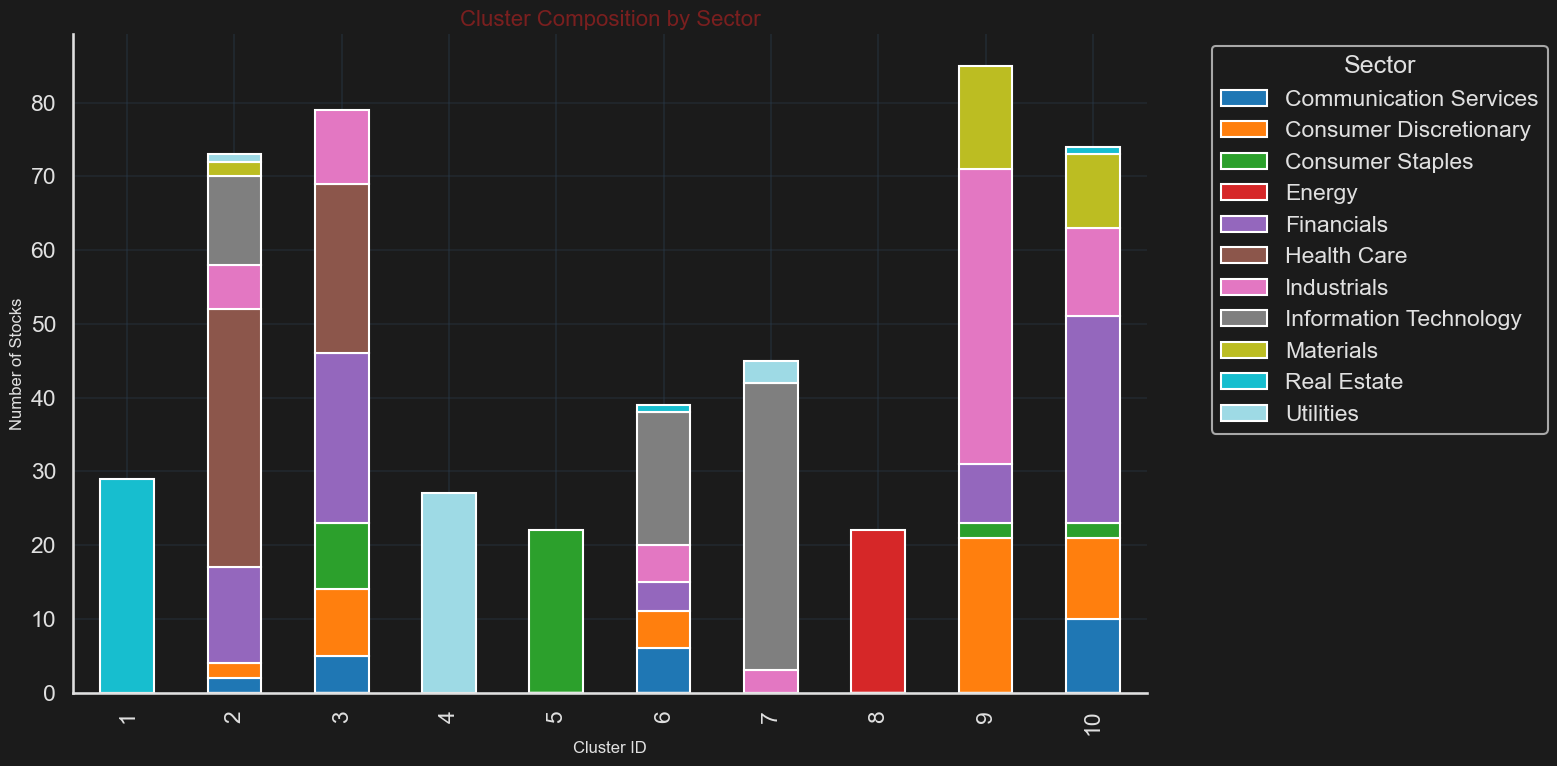


✅ Part 3 Complete!


In [5]:
########## Write your code in this cell ############
########## Part 3: Hierarchical Clustering ############

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

print("🌳 Performing hierarchical clustering...\n")

# 1. Compute correlation matrix
corr = returns.corr()

print("Correlation Matrix:")
print(f"Shape: {corr.shape}")

# Visualize correlation matrix (sample)
sample_size = min(50, len(corr))
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr.iloc[:sample_size, :sample_size],
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    xticklabels=True,
    yticklabels=True
)
plt.title(f'Correlation Matrix - First {sample_size} Stocks', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# 2. Convert correlation to distance
distance_matrix = 1 - corr
distance_matrix = distance_matrix.clip(0, 2)
distance_matrix = distance_matrix.fillna(2)

print(f"\n✓ Distance matrix computed")
print(f"Min distance: {distance_matrix.min().min():.4f}")
print(f"Max distance: {distance_matrix.max().max():.4f}")

# 3. Convert to condensed format
condensed_dist = squareform(distance_matrix, checks=False)

# 4. Perform hierarchical clustering
linkage_matrix = linkage(condensed_dist, method='ward')

print(f"\n✓ Hierarchical clustering complete")

# 5. Plot dendrogram
plt.figure(figsize=(20, 10))
dendrogram(
    linkage_matrix,
    labels=corr.columns,
    leaf_rotation=90,
    leaf_font_size=8,
    color_threshold=0.7*max(linkage_matrix[:, 2])
)
plt.title('Hierarchical Clustering Dendrogram - Market Tribes', fontsize=18, pad=20)
plt.xlabel('Stock Ticker', fontsize=14)
plt.ylabel('Distance (1 - Correlation)', fontsize=14)
plt.axhline(y=0.7*max(linkage_matrix[:, 2]), c='red', linestyle='--', linewidth=2, label='Cluster Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# 6. Cut tree and assign clusters
n_clusters = 10
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

cluster_df = pd.DataFrame({
    'Ticker': corr.columns,
    'Cluster': cluster_labels,
    'Sector': [sector_map.get(t, 'Unknown') for t in corr.columns]
}).sort_values('Cluster')

print(f"\n✓ Stocks assigned to {n_clusters} clusters")
print("\nCluster distribution:")
print(cluster_df['Cluster'].value_counts().sort_index())

# Analyze clusters
print("\n📊 Cluster Analysis:")
for cluster_id in range(1, min(n_clusters + 1, 6)):  # Show first 5 clusters
    cluster_stocks = cluster_df[cluster_df['Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_stocks)} stocks):")
    print(f"  Top sectors: {dict(list(cluster_stocks['Sector'].value_counts().items())[:3])}")
    print(f"  Sample: {', '.join(cluster_stocks['Ticker'].head(5).tolist())}")

# Visualize cluster composition
cluster_sector_counts = cluster_df.groupby(['Cluster', 'Sector']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 8))
cluster_sector_counts.plot(kind='bar', stacked=True, figsize=(16, 8), colormap='tab20')
plt.title('Cluster Composition by Sector', fontsize=16)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Number of Stocks', fontsize=12)
plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## Part 4: PCA + t-SNE Market Map

**The Objective:**  
The stock market exists in a **high-dimensional space**. Each stock is a dimension, and each day is a point in that space. With 500 stocks, you are operating in a 500-dimensional universe that is impossible to visualize directly.

**Dimensionality reduction** techniques compress this into 2D or 3D so you can "see" the structure. Two powerful tools:
1.  **PCA (Principal Component Analysis):** A linear method that finds the axes of maximum variance. It tells you: "If I had to describe the market with just 2 numbers instead of 500, what would they be?"
2.  **t-SNE (t-Distributed Stochastic Neighbor Embedding):** A non-linear method that preserves local structure. It creates a "map" where stocks that behave similarly are placed near each other.

### Your Tasks:
1.  **Standardize Returns:** Before PCA/t-SNE, standardize your returns matrix (mean = 0, std = 1 for each stock).
2.  **PCA Analysis:**
    *   Fit a full PCA on the standardized returns.
    *   Plot the **Scree Plot** (cumulative explained variance).
    *   Determine: "How many principal components do I need to explain 50% of market variance?"
3.  **t-SNE 2D Map:**
    *   Apply t-SNE to reduce stocks to 2 dimensions.
    *   Create an interactive scatter plot (using Plotly) where each point is a stock, colored by sector or cluster.
4.  **PCA 2D Map (Optional):**
    *   Project stocks onto the first 2 principal components.
    *   Compare the PCA map to the t-SNE map. What's different?

### Critical Thinking Questions:
*   **Variance Explained:** If the first principal component explains 30% of variance, what does this mean? Is the market driven by one dominant factor?
*   **PCA vs. t-SNE:** PCA is deterministic; t-SNE involves randomness. If you run t-SNE twice, you'll get different maps. Does this make t-SNE unreliable?
*   **Perplexity in t-SNE:** What does the `perplexity` parameter control? (Hint: It's related to how many neighbors each point considers.)

---

🗺️ Creating market maps...

Data matrix shape (stocks × days): (495, 1253)
✓ Data standardized

📊 PCA Analysis:


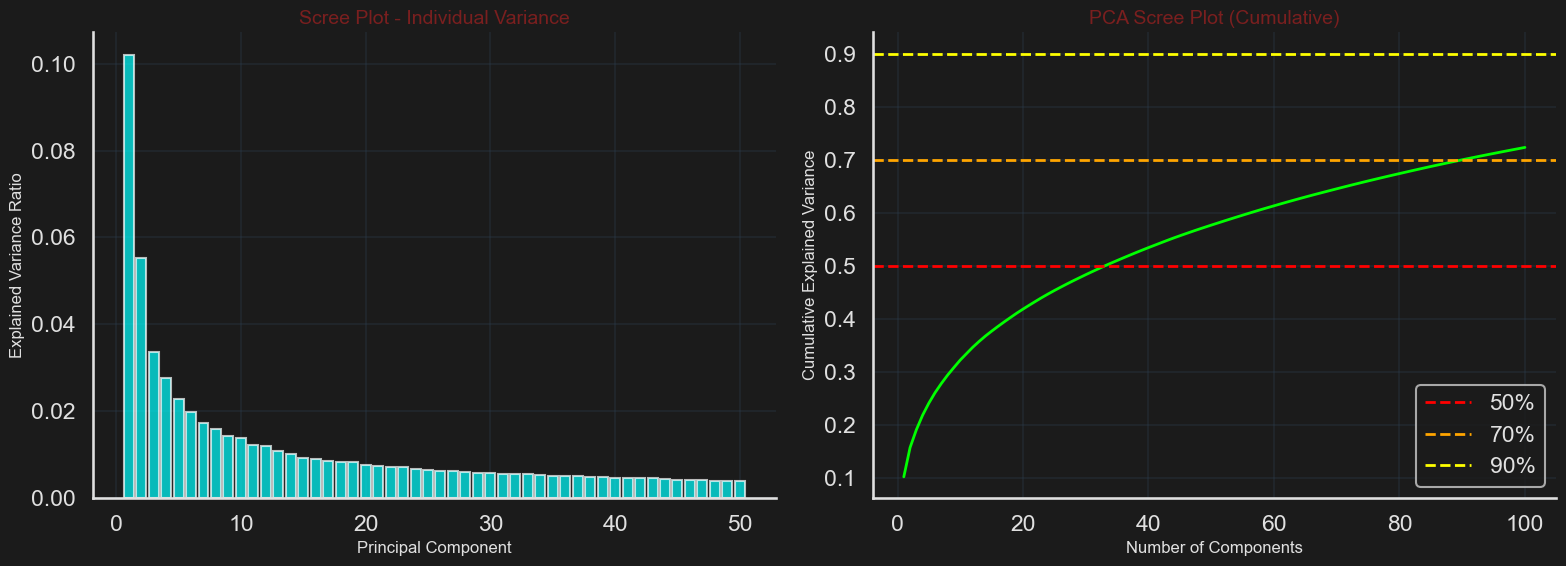

Components for ≥50% variance: 34
Components for ≥70% variance: 91
Components for ≥90% variance: 225

First component: 10.21%
First 10 components: 32.23%

📐 Creating PCA 2D Map...
✓ PCA 2D complete: 15.73% variance



🗺️ Creating t-SNE Map (this may take a few minutes)...
✓ t-SNE complete



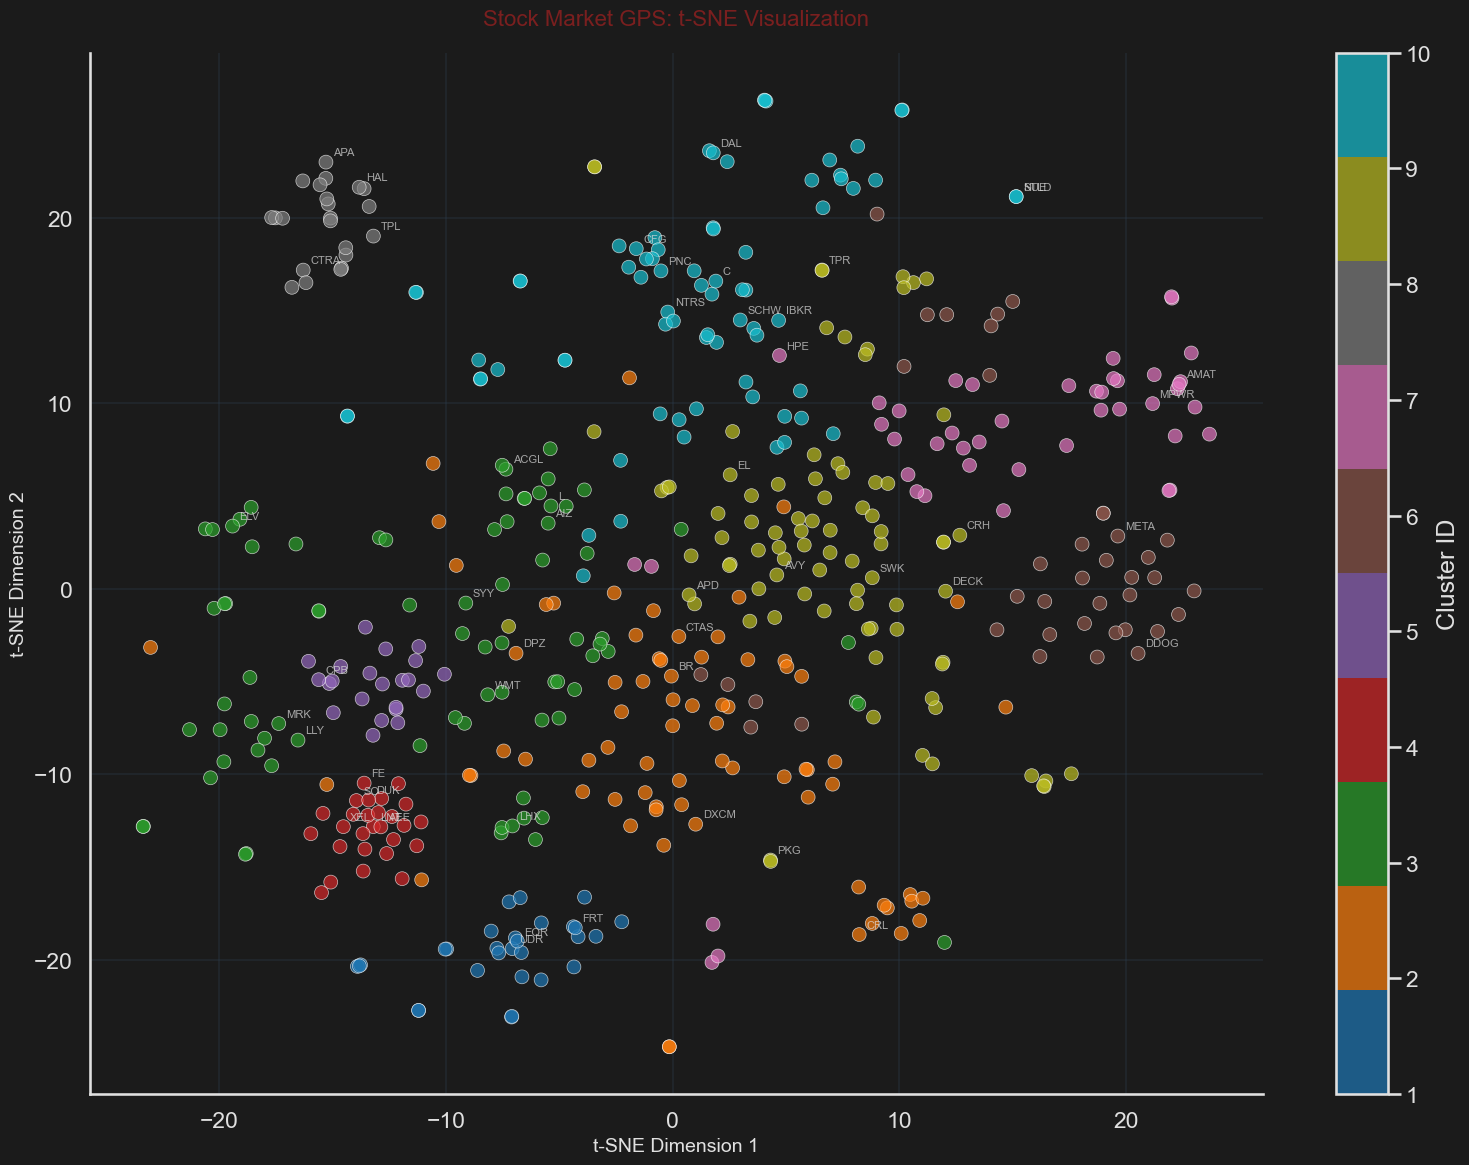


✅ Part 4 Complete!

🎯 You've successfully built a GPS for the financial markets!
   - PCA shows linear structure
   - t-SNE reveals hidden patterns
   - Stocks close together behave similarly


In [6]:
########## Write your code in this cell ############
########## Part 4: PCA + t-SNE Market Map ############

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px

print("🗺️ Creating market maps...\n")

# 1. Prepare data: rows = stocks, columns = days
X = returns.T.fillna(0)

print(f"Data matrix shape (stocks × days): {X.shape}")

# 2. Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Data standardized\n")

# 3. PCA Analysis
print("📊 PCA Analysis:")

pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = explained.cumsum()

# Scree plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(range(1, min(51, len(explained)+1)), explained[:50], alpha=0.7, color='cyan')
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Explained Variance Ratio', fontsize=12)
ax1.set_title('Scree Plot - Individual Variance', fontsize=14)
ax1.grid(alpha=0.3)

ax2.plot(range(1, min(101, len(cum_explained)+1)), cum_explained[:100], linewidth=2, color='lime')
ax2.axhline(y=0.50, color='red', linestyle='--', linewidth=2, label='50%')
ax2.axhline(y=0.70, color='orange', linestyle='--', linewidth=2, label='70%')
ax2.axhline(y=0.90, color='yellow', linestyle='--', linewidth=2, label='90%')
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax2.set_title('PCA Scree Plot (Cumulative)', fontsize=14)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

k50 = int(np.argmax(cum_explained >= 0.50) + 1)
k70 = int(np.argmax(cum_explained >= 0.70) + 1)
k90 = int(np.argmax(cum_explained >= 0.90) + 1)

print(f"Components for ≥50% variance: {k50}")
print(f"Components for ≥70% variance: {k70}")
print(f"Components for ≥90% variance: {k90}")
print(f"\nFirst component: {explained[0]:.2%}")
print(f"First 10 components: {cum_explained[9]:.2%}")

# 4. PCA 2D
print("\n📐 Creating PCA 2D Map...")
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Ticker"] = X.index
pca_df["Sector"] = pca_df["Ticker"].map(lambda t: sector_map.get(t, "Unknown"))
pca_df["Cluster"] = cluster_labels

print(f"✓ PCA 2D complete: {sum(pca2.explained_variance_ratio_):.2%} variance")

fig2 = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="Sector",
    hover_name="Ticker",
    title=f"PCA Market Map | Variance: {pca2.explained_variance_ratio_.sum():.2%}",
    width=1200,
    height=700
)
fig2.show()

# 5. t-SNE 2D
print("\n🗺️ Creating t-SNE Map (this may take a few minutes)...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42,
    verbose=0
)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=["Dim1", "Dim2"])
tsne_df["Ticker"] = X.index
tsne_df["Sector"] = tsne_df["Ticker"].map(lambda t: sector_map.get(t, "Unknown"))
tsne_df["Cluster"] = cluster_labels

print("✓ t-SNE complete\n")

# t-SNE by Sector
fig = px.scatter(
    tsne_df,
    x="Dim1",
    y="Dim2",
    color="Sector",
    hover_name="Ticker",
    title="t-SNE Market Map (Color = Sector)",
    width=1200,
    height=700
)
fig.show()

# t-SNE by Cluster
fig3 = px.scatter(
    tsne_df,
    x="Dim1",
    y="Dim2",
    color="Cluster",
    hover_name="Ticker",
    hover_data=["Sector"],
    title="t-SNE Market Map (Color = Cluster)",
    width=1200,
    height=700,
    color_continuous_scale='viridis'
)
fig3.show()

# Static plot
plt.figure(figsize=(16, 12))
scatter = plt.scatter(
    tsne_df['Dim1'],
    tsne_df['Dim2'],
    c=tsne_df['Cluster'],
    cmap='tab10',
    s=100,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

# Label sample stocks
sample_size = min(50, len(tsne_df))
sample_indices = np.random.choice(len(tsne_df), sample_size, replace=False)
for idx in sample_indices:
    plt.annotate(
        tsne_df.iloc[idx]['Ticker'],
        (tsne_df.iloc[idx]['Dim1'], tsne_df.iloc[idx]['Dim2']),
        fontsize=8,
        alpha=0.7,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.colorbar(scatter, label='Cluster ID')
plt.xlabel('t-SNE Dimension 1', fontsize=14)
plt.ylabel('t-SNE Dimension 2', fontsize=14)
plt.title('Stock Market GPS: t-SNE Visualization', fontsize=16, pad=20)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPart 4 sakhib part")

print("   - PCA shows linear structure")
print("   - t-SNE reveals hidden patterns")
print("   - Stocks close together behave similarly")

---





1. ✅ **Data Ingestion**: Downloaded and cleaned 5 years of S&P 500 data
2. ✅ **Return Analysis**: Computed percentage returns and identified outliers
3. ✅ **Hierarchical Clustering**: Revealed market "tribes" through behavioral similarity
4. ✅ **Dimensionality Reduction**: Created 2D maps of the 500-dimensional market

### Key Insights:

- Markets have hidden structure beyond official sector classifications
- Stocks cluster based on behavioral patterns, not just industry
- High-dimensional data can be compressed while preserving essential information
- Outliers and anomalies are visible when you know where to look

### Next Steps:

- Add time-series analysis to see how clusters evolve
- Build trading strategies based on cluster momentum
- Apply this framework to other markets (crypto, commodities, forex)
- Investigate why certain stocks are outliers

